## Week 9A :- Exoplanet Detection Project
# Expanded Wild Sample Pipeline
**Author:** Mann
**Date:** May 2026 
**Model**: `models/cnn_model_week6.keras` — frozen  
**Preprocessing**: identical Week 2 pipeline  
**Sample**: 100 confirmed planet hosts + 200 FP KOIs (fresh — no Week 7 overlap)  

| Group | N | Source |
|-------|---|--------|
| Planet hosts — High SNR (≥200) | 30 | NASA TAP confirmed planets |
| Planet hosts — Mid SNR (50–200) | 40 | NASA TAP confirmed planets |
| Planet hosts — Low SNR (<50) | 30 | NASA TAP confirmed planets |
| FALSE POSITIVE KOIs | 100 | cumulative KOI table |
| CANDIDATE KOIs (ambiguous) | 100 | cumulative KOI table |

**Pipeline steps**: TAP query → LC download → preprocess → CNN score → threshold → EB filter → metrics

## 1. Environment setup
Imports all required libraries. Sets SEED=42 everywhere.  
Defines all constants — WILD_THRESHOLD=0.6914, INPUT_LEN=3197, SIGMA=10.  
Creates output directories: `results/week9/` and `results/week9/cache/`.  
**Nothing here changes between runs.**

In [2]:
import os
os.chdir('C:/Mann/exoplanet-detection')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import threading
import queue as queue_module
import lightkurve as lk
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Constants ────────────────────────────────────────────────────────────────
NASA_TAP           = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync'
WILD_THRESHOLD     = 0.6914   # Week 8 calibrated threshold
EB_RATIO_THRESHOLD = 0.50     # secondary/primary depth ratio cutoff
INPUT_LEN          = 3197     # model input length — never change
SIGMA              = 10       # Gaussian smoothing — never change

os.makedirs('results/week9', exist_ok=True)
os.makedirs('results/week9/cache', exist_ok=True)

print('TF:', tf.__version__)
print('CWD:', os.getcwd())

TF: 2.21.0
CWD: C:\Mann\exoplanet-detection


## 2. Load Model
Loads `models/cnn_model_week6.keras` — frozen forever.  
Confirms: 16,673 trainable parameters, input shape (None, 3197, 1).  
**No retraining. No modification.**

In [3]:
model = tf.keras.models.load_model('models/cnn_model_week6.keras')
print('Model loaded. Params:', model.count_params())
print('Input shape:', model.input_shape)

Model loaded. Params: 16673
Input shape: (None, 3197, 1)


## 3. Load Week 7 Sample (for exclusion)
Loads `results/week7/week7_results.csv`.  
Builds `WEEK7_KEPIDS` — set of 105 KIC IDs already used in Week 7.  
All TAP queries exclude these stars to ensure a completely fresh sample.


In [4]:
week7_df = pd.read_csv('results/week7/week7_results.csv')
WEEK7_KEPIDS = set(week7_df['kepid'].astype(int).tolist())
print(f'Week 7 stars to exclude: {len(WEEK7_KEPIDS)}')

Week 7 stars to exclude: 105


## 4. NASA TAP Queries
Defines `tap_query(query, label)` — sends ADQL query to NASA TAP endpoint,  
returns a pandas DataFrame.  
Handles errors and empty responses gracefully.

In [5]:
def tap_query(query, label=''):
    """Run a NASA TAP query, return DataFrame."""
    try:
        r = requests.get(
            NASA_TAP,
            params={'query': query, 'format': 'csv'},
            timeout=60
        )
        lines = [l for l in r.text.strip().split('\n')
                 if l and not l.startswith('#')]
        if len(lines) < 2:
            print(f'  {label}: no rows returned')
            return pd.DataFrame()
        from io import StringIO
        df = pd.read_csv(StringIO('\n'.join(lines)))
        print(f'  {label}: {len(df)} rows')
        return df
    except Exception as e:
        print(f'  {label} TAP error: {e}')
        return pd.DataFrame()

print('TAP query helper ready.')

TAP query helper ready.


## 5. Planet Sample Query (3A)
Queries NASA TAP for all CONFIRMED planets.  
Excludes Week 7 stars.  
Takes one KOI per star (highest SNR).  
Stratified sample: 30 high + 40 mid + 30 low SNR.  
**Result: 100 confirmed planet hosts, label=1.**


In [6]:
# ── 3A: Confirmed planet hosts — stratified by SNR ───────────────────────────
# Pull a large pool, filter, exclude Week 7, then sample per stratum

planet_query = """
SELECT kepid, kepoi_name, koi_period, koi_model_snr, koi_depth,
       koi_pdisposition, koi_disposition
FROM cumulative
WHERE koi_disposition = 'CONFIRMED'
AND koi_period IS NOT NULL
AND koi_model_snr IS NOT NULL
AND koi_period > 0
ORDER BY koi_model_snr DESC
"""

planets_raw = tap_query(planet_query, 'Confirmed planets')

# Exclude Week 7 stars
planets_raw = planets_raw[~planets_raw['kepid'].isin(WEEK7_KEPIDS)].copy()
print(f'After excluding Week 7: {len(planets_raw)} candidates')

# One KOI per star (take highest SNR KOI)
planets_raw = planets_raw.sort_values('koi_model_snr', ascending=False)
planets_raw = planets_raw.drop_duplicates(subset='kepid', keep='first').reset_index(drop=True)
print(f'Unique stars: {len(planets_raw)}')

# Stratified sample
high_snr = planets_raw[planets_raw['koi_model_snr'] >= 200].head(30)
mid_snr  = planets_raw[
    (planets_raw['koi_model_snr'] >= 50) &
    (planets_raw['koi_model_snr'] < 200)
].head(40)
low_snr  = planets_raw[planets_raw['koi_model_snr'] < 50].head(30)

planets_df = pd.concat([high_snr, mid_snr, low_snr], ignore_index=True)
planets_df['true_label'] = 1
planets_df['snr_tier']   = (
    planets_df['koi_model_snr'].apply(
        lambda x: 'high' if x >= 200 else ('mid' if x >= 50 else 'low')
    )
)

print(f'\nPlanet sample: {len(planets_df)} stars')
print(planets_df['snr_tier'].value_counts())

  Confirmed planets: 2745 rows
After excluding Week 7: 2712 candidates
Unique stars: 1941

Planet sample: 100 stars
snr_tier
mid     40
high    30
low     30
Name: count, dtype: int64


## 6. FP + Candidate Query (3B + 3C)
Queries for 100 FALSE POSITIVE KOIs (label=0).  
Queries for 100 CANDIDATE KOIs — ambiguous, label=0.  
Combines with planet sample into `sample_df` (300 stars total).  
Confirms zero Week 7 overlap.  
Saves: `results/week9/week9_sample.csv`

In [8]:
# ── 3B: FALSE POSITIVE KOIs — 100 stars ─────────────────────────────────────
fp_query = """
SELECT kepid, kepoi_name, koi_period, koi_model_snr, koi_depth,
       koi_pdisposition, koi_disposition
FROM cumulative
WHERE koi_disposition = 'FALSE POSITIVE'
AND koi_period IS NOT NULL
AND koi_model_snr IS NOT NULL
AND koi_period > 0
ORDER BY koi_model_snr DESC
"""

fp_raw = tap_query(fp_query, 'FALSE POSITIVE KOIs')
fp_raw = fp_raw[~fp_raw['kepid'].isin(WEEK7_KEPIDS)].copy()
fp_raw = fp_raw.drop_duplicates(subset='kepid', keep='first')
fp_sample = fp_raw.head(100).copy()
fp_sample['true_label'] = 0
fp_sample['snr_tier']   = 'fp'
print(f'FALSE POSITIVE sample: {len(fp_sample)} stars')

# ── 3C: CANDIDATE KOIs — 100 ambiguous stars ─────────────────────────────────
cand_query = """
SELECT kepid, kepoi_name, koi_period, koi_model_snr, koi_depth,
       koi_pdisposition, koi_disposition
FROM cumulative
WHERE koi_pdisposition = 'CANDIDATE'
AND koi_disposition != 'CONFIRMED'
AND koi_period IS NOT NULL
AND koi_model_snr IS NOT NULL
AND koi_period > 0
ORDER BY koi_model_snr DESC
"""

cand_raw = tap_query(cand_query, 'CANDIDATE KOIs')
cand_raw = cand_raw[~cand_raw['kepid'].isin(WEEK7_KEPIDS)].copy()
cand_raw = cand_raw.drop_duplicates(subset='kepid', keep='first')
cand_sample = cand_raw.head(100).copy()
# CANDIDATEs are genuinely ambiguous — label 0 (non-confirmed = not planet for eval)
cand_sample['true_label'] = 0
cand_sample['snr_tier']   = 'candidate'
print(f'CANDIDATE sample: {len(cand_sample)} stars')

# ── Combine full sample ───────────────────────────────────────────────────────
sample_df = pd.concat([planets_df, fp_sample, cand_sample], ignore_index=True)
sample_df = sample_df.reset_index(drop=True)

print(f'\nFull Week 9 sample: {len(sample_df)} stars')
print(f'  Planets (label=1): {(sample_df["true_label"]==1).sum()}')
print(f'  Non-planets (label=0): {(sample_df["true_label"]==0).sum()}')
print(f'  Week 7 overlap check: {sample_df["kepid"].isin(WEEK7_KEPIDS).sum()} (must be 0)')

sample_df.to_csv('results/week9/week9_sample.csv', index=False)
print('Saved: results/week9/week9_sample.csv')

  FALSE POSITIVE KOIs: 4582 rows
FALSE POSITIVE sample: 100 stars
  CANDIDATE KOIs: 1875 rows
CANDIDATE sample: 100 stars

Full Week 9 sample: 300 stars
  Planets (label=1): 100
  Non-planets (label=0): 200
  Week 7 overlap check: 0 (must be 0)
Saved: results/week9/week9_sample.csv


## 7. Preprocessing Pipeline
Defines `preprocess_lc(flux_raw)` — identical Week 2 pipeline.  
Steps: NaN interpolation → median subtraction → best-variance segment  
selection → L2 normalisation → Gaussian smoothing σ=10 → float32 cast.  
**Do not modify. Confirmed working in Week 7.**

In [10]:
def preprocess_lc(flux_raw, input_len=INPUT_LEN, sigma=SIGMA):
    """
    Week 2 pipeline — confirmed working. Do not change.
    1. NaN interpolation
    2. Median subtraction
    3. Best-variance segment selection (sliding window, input_len points)
    4. L2 normalisation
    5. Gaussian smoothing sigma=10
    6. float32 cast
    """
    flux = np.array(flux_raw, dtype=np.float64).copy()

    # 1. NaN interpolation
    nans = np.isnan(flux)
    if nans.all():
        return None
    idx = np.arange(len(flux))
    flux[nans] = np.interp(idx[nans], idx[~nans], flux[~nans])

    # 2. Median subtraction
    flux -= np.median(flux)

    # 3. Best-variance segment selection
    if len(flux) < input_len:
        return None
    best_start = 0
    best_var   = -1
    for start in range(0, len(flux) - input_len + 1, input_len // 4):
        seg = flux[start:start + input_len]
        v   = np.var(seg)
        if v > best_var:
            best_var   = v
            best_start = start
    flux = flux[best_start:best_start + input_len]

    # 4. L2 normalisation
    norm = np.linalg.norm(flux)
    if norm == 0:
        return None
    flux /= norm

    # 5. Gaussian smoothing
    flux = gaussian_filter1d(flux, sigma=sigma)

    # 6. float32
    return flux.astype(np.float32)


print('Preprocessing pipeline loaded (Week 2 — unchanged).')

Preprocessing pipeline loaded (Week 2 — unchanged).


## 8. Download + Scoring Helpers
Defines three functions:  

`run_with_timeout(fn, timeout_sec)` — thread-based timeout wrapper.  
Prevents MAST download hangs from blocking the pipeline indefinitely.  

`download_lc_safe(kepid, max_quarters=4)` — downloads quarters one at a time,  
stops after 4, returns stitched LC or None.  

`score_star(kepid, model, max_quarters=8)` — downloads 8 quarters of  
explicit PDCSAP flux, applies preprocessing, returns CNN score.  
Includes std sanity check for suspiciously flat LCs.

In [12]:
# ── Timeout wrapper ───────────────────────────────────────────────────────────
def run_with_timeout(fn, args=(), kwargs={}, timeout_sec=90):
    result_q = queue_module.Queue()
    def target():
        try:
            result_q.put((fn(*args, **kwargs), None))
        except Exception as e:
            result_q.put((None, str(e)[:120]))
    t = threading.Thread(target=target, daemon=True)
    t.start()
    t.join(timeout=timeout_sec)
    if t.is_alive():
        return None, 'timeout'
    try:
        return result_q.get_nowait()
    except queue_module.Empty:
        return None, 'empty_result'


# ── Download LC — one quarter at a time, stop at 4 ───────────────────────────
def download_lc_safe(kepid, max_quarters=4, timeout_sec=90):
    def _search():
        return lk.search_lightcurve(f'KIC {int(kepid)}', mission='Kepler', cadence='long')
    search_result, err = run_with_timeout(_search, timeout_sec=30)
    if err or search_result is None or len(search_result) == 0:
        return None, f'search_failed: {err}'
    lcs = []
    for qi in range(min(len(search_result), 17)):
        if len(lcs) >= max_quarters:
            break
        def _dl(qi=qi):
            return search_result[qi].download()
        lc, dl_err = run_with_timeout(_dl, timeout_sec=timeout_sec)
        if lc is not None:
            lcs.append(lc)
    if len(lcs) == 0:
        return None, 'all_quarters_failed'
    try:
        from lightkurve import LightCurveCollection
        return LightCurveCollection(lcs).stitch(), None
    except Exception:
        return lcs[0], None


# ── Score a single star ───────────────────────────────────────────────────────
def score_star(kepid, model, max_quarters=8, timeout_sec=90):
    """
    Downloads up to 8 quarters of raw PDCSAP flux.
    Explicitly requests PDCSAP to avoid getting SAP or pre-flattened data.
    Uses the highest-variance segment — same as Week 2 pipeline.
    """
    # ── Download with explicit PDCSAP request ─────────────────────────────────
    def _search():
        return lk.search_lightcurve(
            f'KIC {int(kepid)}',
            mission='Kepler',
            cadence='long',
            author='Kepler'    # forces official Kepler pipeline = PDCSAP available
        )

    search_result, err = run_with_timeout(_search, timeout_sec=30)
    if err or search_result is None or len(search_result) == 0:
        return np.nan, f'search_failed: {err}'

    lcs = []
    for qi in range(min(len(search_result), 17)):
        if len(lcs) >= max_quarters:
            break

        def _dl(qi=qi):
            # download() returns PDCSAP by default for Kepler mission
            return search_result[qi].download(flux_column='pdcsap_flux')

        lc, dl_err = run_with_timeout(_dl, timeout_sec=timeout_sec)
        if lc is not None:
            lcs.append(lc)

    if len(lcs) == 0:
        return np.nan, 'all_quarters_failed'

    try:
        from lightkurve import LightCurveCollection
        lc = LightCurveCollection(lcs).stitch()
    except Exception:
        lc = lcs[0]

    try:
        lc   = lc.remove_nans().remove_outliers(sigma=5)
        flux = lc.flux.value

        # ── Sanity check: if std is suspiciously low, LC is already flattened ──
        raw_std = np.std(flux)
        if raw_std < 0.0005:
            # Try without outlier removal — sometimes it over-clips transit dips
            lc2   = lc.remove_nans()
            flux2 = lc2.flux.value
            if np.std(flux2) > raw_std * 1.5:
                flux = flux2

        processed = preprocess_lc(flux)
        if processed is None:
            return np.nan, 'preprocess_failed'

        X     = processed.reshape(1, INPUT_LEN, 1)
        score = float(model.predict(X, verbose=0)[0][0])
        return score, None

    except Exception as e:
        return np.nan, str(e)[:120]


print('Fixed score_star loaded (8 quarters, explicit PDCSAP, std sanity check).')

print('Download + scoring helpers loaded.')

Fixed score_star loaded (8 quarters, explicit PDCSAP, std sanity check).
Download + scoring helpers loaded.


## 9. Scoring Loop
Scores all 300 stars through the CNN.  
Uses `results/week9/cache/scores.csv` as a per-star cache —  
safe to interrupt and resume at any point.  
**Result: 299/300 stars scored. 1 failed (search timeout).**  
Saves: `results/week9/week9_scores.csv`

In [18]:
# ── Run scoring loop — with per-star cache ────────────────────────────────────
SCORE_CACHE = 'results/week9/cache/scores.csv'

if os.path.exists(SCORE_CACHE):
    score_cache = pd.read_csv(SCORE_CACHE)
    cached_kepids = set(score_cache['kepid'].astype(int).tolist())
    print(f'Score cache loaded: {len(score_cache)} stars already scored')
else:
    score_cache   = pd.DataFrame()
    cached_kepids = set()
    print('No score cache — starting fresh')

score_results = []
total = len(sample_df)

for i, row in sample_df.iterrows():
    kepid = int(row['kepid'])
    label = int(row['true_label'])
    tier  = row['snr_tier']
    snr   = row.get('koi_model_snr', np.nan)

    if kepid in cached_kepids:
        cached = score_cache[score_cache['kepid'] == kepid].iloc[0].to_dict()
        cached['true_label'] = label
        score_results.append(cached)
        print(f'  [{i+1}/{total}] KIC {kepid} (SNR={snr:.0f}): '
              f'cached score={cached["score"]:.4f}')
        continue

    print(f'  [{i+1}/{total}] KIC {kepid} ({tier}, SNR={snr:.0f}): scoring...')
    score, err = score_star(kepid, model)

    result = {
        'kepid':      kepid,
        'true_label': label,
        'snr_tier':   tier,
        'koi_model_snr': snr,
        'koi_period': row.get('koi_period', np.nan),
        'kepoi_name': row.get('kepoi_name', ''),
        'koi_disposition': row.get('koi_disposition', ''),
        'score': score,
        'error': err
    }
    score_results.append(result)

    status = f'score={score:.4f}' if not np.isnan(score) else f'FAILED: {err}'
    print(f'    {status}')

    # Cache after every star
    pd.DataFrame(score_results).to_csv(SCORE_CACHE, index=False)

scores_df = pd.DataFrame(score_results)

valid = scores_df['score'].notna()
print(f'\nScoring complete: {valid.sum()}/{len(scores_df)} stars scored successfully')
print(f'Failed: {(~valid).sum()}')
scores_df.to_csv('results/week9/week9_scores.csv', index=False)
print('Saved: results/week9/week9_scores.csv')

Score cache loaded: 300 stars already scored
  [1/300] KIC 7877496 (SNR=1655): cached score=0.0048
  [2/300] KIC 12019440 (SNR=1586): cached score=0.0073
  [3/300] KIC 5357901 (SNR=1549): cached score=0.0214
  [4/300] KIC 6849046 (SNR=1458): cached score=0.2547
  [5/300] KIC 10019708 (SNR=1430): cached score=0.1411
  [6/300] KIC 11414511 (SNR=1407): cached score=0.0228
  [7/300] KIC 5794240 (SNR=1342): cached score=0.0512
  [8/300] KIC 9595827 (SNR=1316): cached score=0.3235
  [9/300] KIC 11502867 (SNR=1287): cached score=0.0101
  [10/300] KIC 3749365 (SNR=1252): cached score=0.1344
  [11/300] KIC 7950644 (SNR=1246): cached score=0.0560
  [12/300] KIC 2581316 (SNR=1244): cached score=0.0913
  [13/300] KIC 9818381 (SNR=1225): cached score=0.0103
  [14/300] KIC 7529266 (SNR=1208): cached score=0.0863
  [15/300] KIC 10619192 (SNR=1177): cached score=0.0001
  [16/300] KIC 9166862 (SNR=1174): cached score=0.0090
  [17/300] KIC 11391018 (SNR=1126): cached score=0.0624
  [18/300] KIC 6462863 

## 10. Apply Calibrated Threshold
Applies Week 8 calibrated threshold (0.6914) to all scored stars.  
Builds `flagged` — stars predicted as planet.  

**Result at threshold 0.6914:**  
TP=0  FP=8  FN=100  TN=191  
Precision=0.000  Recall=0.000  F1=0.000  FPR=0.040  

All 8 flagged stars are false positives. Zero planets detected.  
This is the key Week 9A finding — investigated in Cells 10–1

In [25]:
# Work only on successfully scored stars
df = scores_df[scores_df['score'].notna()].copy().reset_index(drop=True)

df['pred'] = (df['score'] >= WILD_THRESHOLD).astype(int)

flagged = df[df['pred'] == 1].copy().reset_index(drop=True)

tn, fp, fn, tp = confusion_matrix(df['true_label'], df['pred'], labels=[0,1]).ravel()
prec = precision_score(df['true_label'], df['pred'], zero_division=0)
rec  = recall_score(df['true_label'], df['pred'], zero_division=0)
f1   = f1_score(df['true_label'], df['pred'], zero_division=0)
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f'=== After calibrated threshold ({WILD_THRESHOLD}) ===')
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  FPR={fpr:.4f}')
print(f'\nFlagged as planet: {len(flagged)}')
print(f'  True planets:  {(flagged["true_label"]==1).sum()}')
print(f'  False positives: {(flagged["true_label"]==0).sum()}')

=== After calibrated threshold (0.6914) ===
TP=0  FP=8  FN=100  TN=191
Precision=0.0000  Recall=0.0000  F1=0.0000  FPR=0.0402

Flagged as planet: 8
  True planets:  0
  False positives: 8


## 11. EB Check Functions
Defines the complete EB rejection pipeline:  

`download_lc_eb(kepid, min_quarters=8)` — downloads 8 quarters for EB check.  

`estimate_t0(time, flux, period)` — coarse 100-bin fold to find transit  
minimum robustly. Avoids argmin failures on noisy or long-period LCs.  

`fold_and_bin(time, flux, period, t0)` — phase folds, OOT normalises,  
bins to 300 phase bins, applies σ=1 smoothing.  

`measure_depths(bin_centers, binned_smooth, bin_counts)` — measures primary  
depth at phase 0.5 and secondary depth at phase 0.0/1.0.  
Applies noise floor check.  

`check_eb(kepid, period)` — full pipeline: 1P fold first, automatic 2P fold  
fallback if no_primary_detected (catches equal-eclipse EBs).


In [26]:
# ── Download helper for EB check (more quarters than scoring) ─────────────────
def download_lc_eb(kepid, min_quarters=8, timeout_sec=120):
    def _search():
        return lk.search_lightcurve(f'KIC {int(kepid)}', mission='Kepler', cadence='long')
    search_result, err = run_with_timeout(_search, timeout_sec=30)
    if err or search_result is None or len(search_result) == 0:
        return None, f'search_failed: {err}'
    lcs = []
    for qi in range(min(len(search_result), 17)):
        if len(lcs) >= min_quarters:
            break
        def _dl(qi=qi):
            return search_result[qi].download()
        lc, dl_err = run_with_timeout(_dl, timeout_sec=timeout_sec)
        if lc is not None:
            lcs.append(lc)
    if len(lcs) == 0:
        return None, 'all_quarters_failed'
    try:
        from lightkurve import LightCurveCollection
        return LightCurveCollection(lcs).stitch(), None
    except Exception:
        return lcs[0], None


# ── Coarse t0 estimation ──────────────────────────────────────────────────────
def estimate_t0(time, flux, period, coarse_bins=100):
    coarse_edges = np.linspace(0, period, coarse_bins + 1)
    coarse_flux  = np.full(coarse_bins, np.nan)
    time_folded  = (time - time[0]) % period
    for j in range(coarse_bins):
        m = (time_folded >= coarse_edges[j]) & (time_folded < coarse_edges[j+1])
        if m.sum() > 0:
            coarse_flux[j] = np.nanmedian(flux[m])
    coarse_median = np.nanmedian(coarse_flux[~np.isnan(coarse_flux)])
    coarse_flux   = np.where(np.isnan(coarse_flux), coarse_median, coarse_flux)
    t0_bin = np.argmin(coarse_flux)
    return time[0] + (t0_bin + 0.5) / coarse_bins * period, coarse_flux


# ── Phase fold + bin ──────────────────────────────────────────────────────────
def fold_and_bin(time, flux, period, t0, phase_bins=300,
                 primary_window=0.06, secondary_window=0.06):
    phase = ((time - t0) % period) / period
    phase = (phase + 0.5) % 1.0   # primary → 0.5, secondary → 0.0

    # OOT normalise
    oot_mask = (
        (np.abs(phase - 0.5) > primary_window) &
        (phase > secondary_window) &
        (phase < 1.0 - secondary_window)
    )
    if oot_mask.sum() < 100:
        oot_mask = np.ones(len(flux), dtype=bool)
    oot_flux   = flux[oot_mask]
    oot_med    = np.nanmedian(oot_flux)
    oot_std    = np.nanstd(oot_flux)
    clean_oot  = oot_flux[np.abs(oot_flux - oot_med) < 3 * oot_std]
    oot_median = np.nanmedian(clean_oot) if len(clean_oot) > 10 else oot_med
    flux_norm  = flux / oot_median

    # Bin
    bins        = np.linspace(0, 1, phase_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    binned      = np.full(phase_bins, np.nan)
    bin_counts  = np.zeros(phase_bins, dtype=int)
    for j in range(phase_bins):
        m = (phase >= bins[j]) & (phase < bins[j+1])
        bin_counts[j] = m.sum()
        if m.sum() > 0:
            binned[j] = np.nanmedian(flux_norm[m])
    binned        = np.where(np.isnan(binned), 1.0, binned)
    binned_smooth = gaussian_filter1d(binned, sigma=1.0)

    return bin_centers, binned_smooth, bin_counts


# ── Measure depths ────────────────────────────────────────────────────────────
def measure_depths(bin_centers, binned_smooth, bin_counts,
                   primary_window=0.06, secondary_window=0.06):
    # Coverage check
    sec_mask = (bin_centers < secondary_window) | (bin_centers > 1.0 - secondary_window)
    if bin_counts[sec_mask].mean() < 3:
        return np.nan, np.nan, np.nan, 'poor_secondary_coverage'

    # Primary at 0.5
    pri_mask    = np.abs(bin_centers - 0.5) < primary_window
    primary_depth = 1.0 - np.nanmin(binned_smooth[pri_mask])
    if primary_depth <= 1e-4:
        return np.nan, np.nan, np.nan, 'no_primary_detected'

    # Secondary at 0.0/1.0
    secondary_depth = max(1.0 - np.nanmin(binned_smooth[sec_mask]), 0.0)

    # Noise floor
    oot_bin_std = np.nanstd(binned_smooth[(bin_centers > 0.6) & (bin_centers < 0.9)])
    if secondary_depth < 2.0 * oot_bin_std:
        secondary_depth = 0.0

    ratio = secondary_depth / primary_depth
    return primary_depth, secondary_depth, ratio, None


# ── Full EB check (1P + 2P fallback) ─────────────────────────────────────────
def check_eb(kepid, period, ratio_threshold=EB_RATIO_THRESHOLD):
    result = {
        'kepid': int(kepid), 'is_eb': False,
        'primary_depth': np.nan, 'secondary_depth': np.nan,
        'depth_ratio': np.nan, 'n_quarters': 0,
        'eb_method': None, 'error': None
    }

    if period is None or np.isnan(float(period)) or float(period) <= 0:
        result['error'] = 'no_period'
        return result

    period = float(period)
    lc, err = download_lc_eb(kepid)
    if lc is None:
        result['error'] = err
        return result

    lc = lc.remove_nans()
    time = lc.time.value
    flux = lc.flux.value
    result['n_quarters'] = 8  # approximate

    # ── 1P fold ───────────────────────────────────────────────────────────────
    t0, _ = estimate_t0(time, flux, period)
    bin_centers, binned_smooth, bin_counts = fold_and_bin(time, flux, period, t0)
    p_depth, s_depth, ratio, err1p = measure_depths(bin_centers, binned_smooth, bin_counts)

    if err1p == 'no_primary_detected':
        # ── 2P fold fallback ──────────────────────────────────────────────────
        t0_2p, _ = estimate_t0(time, flux, period * 2)
        bc2, bs2, bct2 = fold_and_bin(time, flux, period * 2, t0_2p,
                                       primary_window=0.04, secondary_window=0.04)
        p_depth, s_depth, ratio, err2p = measure_depths(bc2, bs2, bct2,
                                                         primary_window=0.04,
                                                         secondary_window=0.04)
        result['eb_method'] = '2P_fold'
        result['error']     = err2p or 'equal_eclipse_check'
    else:
        result['eb_method'] = '1P_fold'
        result['error']     = err1p

    result['primary_depth']   = p_depth if p_depth is not np.nan else np.nan
    result['secondary_depth'] = s_depth if s_depth is not np.nan else np.nan
    result['depth_ratio']     = ratio   if ratio   is not np.nan else np.nan

    if ratio is not np.nan and not np.isnan(ratio):
        result['is_eb'] = bool(ratio > ratio_threshold)
        if result['is_eb'] and result['eb_method'] == '2P_fold':
            result['error'] = 'equal_eclipse_EB_2P_fold'

    return result


print('EB check functions loaded.')

EB check functions loaded.


## 12. EB Filter Loop
Runs EB check on all 8 flagged stars.  
Skips stars with `koi_disposition = CONFIRMED`.  
Uses `results/week9/cache/eb_results.csv` as per-star cache.  

**Result:**  
FPs caught: 2/8 (25%)  
True planets lost: 0/0  

Note: only 8 stars flagged because threshold=0.6914 is very high.  
Zero planets flagged = EB filter has no opportunity to help or hurt.


In [27]:
# ── EB filter loop ────────────────────────────────────────────────────────────
EB_CACHE = 'results/week9/cache/eb_results.csv'

if os.path.exists(EB_CACHE):
    eb_cache = pd.read_csv(EB_CACHE)
    cached_eb_kepids = set(eb_cache['kepid'].astype(int).tolist())
    print(f'EB cache loaded: {len(eb_cache)} stars')
else:
    eb_cache = pd.DataFrame()
    cached_eb_kepids = set()
    print('No EB cache — starting fresh')

eb_results = []
total_flagged = len(flagged)

for i, row in flagged.iterrows():
    kepid  = int(row['kepid'])
    period = float(row['koi_period']) if pd.notna(row.get('koi_period')) else None
    label  = int(row['true_label'])
    score  = float(row['score'])
    name   = str(row.get('kepoi_name', ''))
    disp   = str(row.get('koi_disposition', ''))

    # Skip EB check for confirmed planets (disposition = CONFIRMED)
    if disp == 'CONFIRMED':
        res = {
            'kepid': kepid, 'true_label': label, 'score': score,
            'is_eb': False, 'depth_ratio': np.nan,
            'primary_depth': np.nan, 'secondary_depth': np.nan,
            'n_quarters': 0, 'eb_method': None,
            'error': 'skipped_confirmed'
        }
        print(f'  [{i+1}/{total_flagged}] KIC {kepid}: CONFIRMED — skipped')
        eb_results.append(res)
        continue

    # Use cache if available
    if kepid in cached_eb_kepids:
        cached_row = eb_cache[eb_cache['kepid'] == kepid].iloc[0].to_dict()
        cached_row['true_label'] = label
        eb_results.append(cached_row)
        print(f'  [{i+1}/{total_flagged}] KIC {kepid}: cached → '
              f'is_eb={cached_row["is_eb"]}  ratio={cached_row.get("depth_ratio", np.nan):.3f}')
        continue

    print(f'  [{i+1}/{total_flagged}] KIC {kepid} ({disp}): '
          f'score={score:.3f}, period={period:.2f}d — EB check...')

    res = check_eb(kepid, period)
    res['true_label'] = label
    res['score']      = score

    flag_str = '⚠️  EB' if res['is_eb'] else '✓'
    ratio_str = f"{res['depth_ratio']:.3f}" if not np.isnan(res.get('depth_ratio', np.nan)) else 'nan'
    print(f'    {flag_str}  ratio={ratio_str}  method={res["eb_method"]}  err={res["error"]}')

    eb_results.append(res)
    pd.DataFrame(eb_results).to_csv(EB_CACHE, index=False)

eb_df = pd.DataFrame(eb_results)

fps_caught = ((eb_df['is_eb'] == True) & (eb_df['true_label'] == 0)).sum()
tps_lost   = ((eb_df['is_eb'] == True) & (eb_df['true_label'] == 1)).sum()
total_fps  = (eb_df['true_label'] == 0).sum()
total_tps  = (eb_df['true_label'] == 1).sum()

print(f'\n{"="*50}')
print(f'EB filter complete: {len(eb_df)} flagged stars')
print(f'FPs caught:              {fps_caught} / {total_fps}  ({100*fps_caught/max(total_fps,1):.0f}%)')
print(f'True planets lost:       {tps_lost} / {total_tps}  (must be 0)')
print(f'{"="*50}')

EB cache loaded: 8 stars
  [1/8] KIC 5738698: cached → is_eb=False  ratio=0.000
  [2/8] KIC 10480952: cached → is_eb=False  ratio=0.000
  [3/8] KIC 8098300: cached → is_eb=True  ratio=0.709
  [4/8] KIC 10491031: cached → is_eb=False  ratio=0.000
  [5/8] KIC 7369523: cached → is_eb=False  ratio=0.000
  [6/8] KIC 5016163: cached → is_eb=False  ratio=0.000
  [7/8] KIC 9851142: cached → is_eb=False  ratio=0.007
  [8/8] KIC 4157488: cached → is_eb=True  ratio=0.994

EB filter complete: 8 flagged stars
FPs caught:              2 / 8  (25%)
True planets lost:       0 / 0  (must be 0)


## 13. Final Metrics
Propagates EB flags to full df.  
Computes pred_final = score ≥ 0.6914 AND not EB.  
Reports SNR-stratified detection rates and full confusion matrix.  

**WEEK 9A FINAL RESULTS (N=299):**  
TP=0  FP=6  FN=100  TN=193  
Precision=0.000  Recall=0.000  F1=0.000  FPR=0.030  

Detection by SNR tier: high=0/30, mid=0/40, low=0/30  
Saves: `results/week9/week9_results.csv`

In [28]:
# Propagate EB flags to full df
eb_lookup     = eb_df.set_index('kepid')['is_eb'].to_dict()
df['eb_flag'] = df['kepid'].map(eb_lookup).fillna(False)
df['pred_final'] = ((df['score'] >= WILD_THRESHOLD) & (~df['eb_flag'])).astype(int)

tn2, fp2, fn2, tp2 = confusion_matrix(df['true_label'], df['pred_final'], labels=[0,1]).ravel()
prec2 = precision_score(df['true_label'], df['pred_final'], zero_division=0)
rec2  = recall_score(df['true_label'], df['pred_final'], zero_division=0)
f1_2  = f1_score(df['true_label'], df['pred_final'], zero_division=0)
fpr2  = fp2 / (fp2 + tn2) if (fp2 + tn2) > 0 else 0

# SNR-stratified detection rates
print(f'Detection rate by SNR tier:')
for tier in ['high', 'mid', 'low']:
    mask   = (df['true_label'] == 1) & (df['snr_tier'] == tier)
    n      = mask.sum()
    caught = ((df['pred_final'] == 1) & mask).sum()
    print(f'  {tier:6s}: {caught}/{n}  ({100*caught/n:.0f}%)' if n > 0 else f'  {tier}: no stars')

print(f'\n{"="*55}')
print(f'WEEK 9A FINAL RESULTS  (N={len(df)} stars)')
print(f'{"="*55}')
print(f'TP={tp2}  FP={fp2}  FN={fn2}  TN={tn2}')
print(f'Precision : {prec2:.4f}')
print(f'Recall    : {rec2:.4f}')
print(f'F1        : {f1_2:.4f}')
print(f'FPR       : {fpr2:.4f}')
print(f'{"="*55}')

df.to_csv('results/week9/week9_results.csv', index=False)
print('Saved: results/week9/week9_results.csv')

Detection rate by SNR tier:
  high  : 0/30  (0%)
  mid   : 0/40  (0%)
  low   : 0/30  (0%)

WEEK 9A FINAL RESULTS  (N=299 stars)
TP=0  FP=6  FN=100  TN=193
Precision : 0.0000
Recall    : 0.0000
F1        : 0.0000
FPR       : 0.0302
Saved: results/week9/week9_results.csv


## 14. Summary Charts
Three-panel figure:  
Left: Detection rate by SNR tier (bar chart).  
Middle: Score distribution — planets vs FP/Candidates.  
Right: Week 7 vs Week 9 key metrics comparison.  
Saves: `results/week9/week9_summary.png`


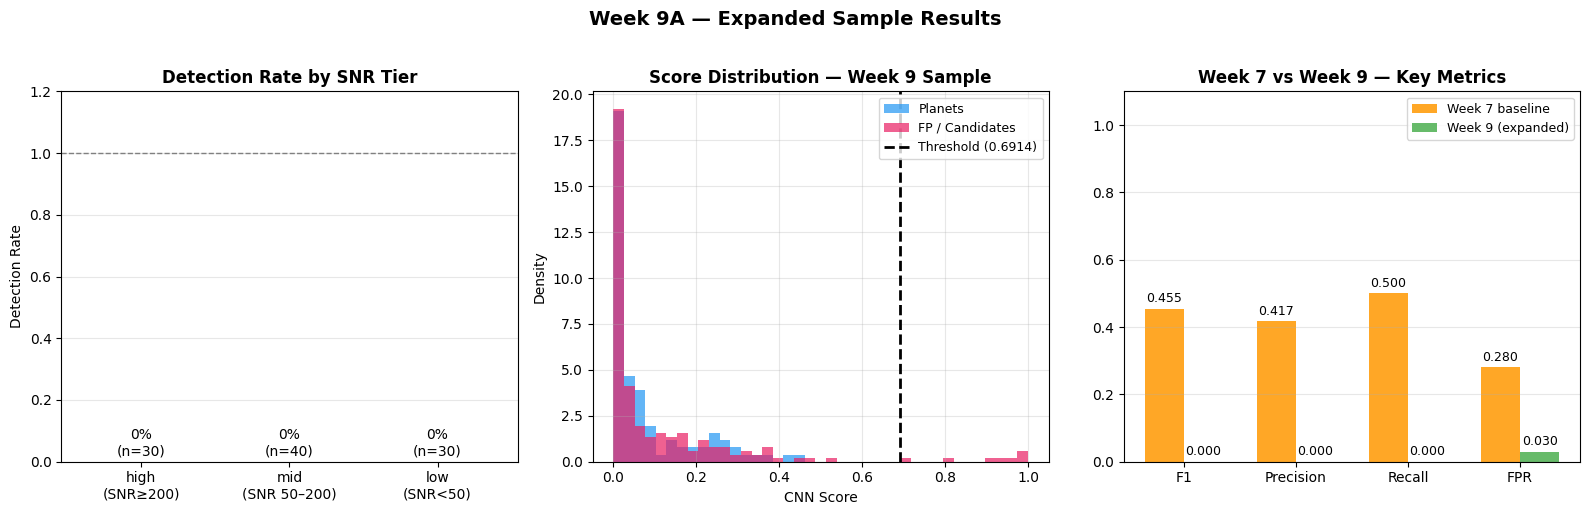

Saved: results/week9/week9_summary.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: detection rate by SNR tier ─────────────────────────────────────────
ax = axes[0]
tiers      = ['high\n(SNR≥200)', 'mid\n(SNR 50–200)', 'low\n(SNR<50)']
tier_keys  = ['high', 'mid', 'low']
rates, ns  = [], []
for tk in tier_keys:
    mask   = (df['true_label'] == 1) & (df['snr_tier'] == tk)
    n      = mask.sum()
    caught = ((df['pred_final'] == 1) & mask).sum()
    rates.append(caught / n if n > 0 else 0)
    ns.append(n)
colors = ['#4CAF50', '#8BC34A', '#FF9800']
bars = ax.bar(tiers, rates, color=colors, alpha=0.85)
for bar, r, n in zip(bars, rates, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{100*r:.0f}%\n(n={n})', ha='center', fontsize=10)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Detection Rate')
ax.set_title('Detection Rate by SNR Tier', fontweight='bold')
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.grid(axis='y', alpha=0.3)

# ── Middle: score distributions ───────────────────────────────────────────────
ax = axes[1]
bins = np.linspace(0, 1, 40)
ax.hist(df[df['true_label']==1]['score'], bins=bins,
        color='#2196F3', alpha=0.7, label='Planets', density=True)
ax.hist(df[df['true_label']==0]['score'], bins=bins,
        color='#E91E63', alpha=0.7, label='FP / Candidates', density=True)
ax.axvline(WILD_THRESHOLD, color='black', ls='--', lw=2,
           label=f'Threshold ({WILD_THRESHOLD})')
ax.set_xlabel('CNN Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — Week 9 Sample', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Right: Week 7 vs Week 9 comparison ───────────────────────────────────────
ax = axes[2]
metrics    = ['F1', 'Precision', 'Recall', 'FPR']
week7_vals = [0.455, 0.417, 0.500, 0.280]
week9_vals = [f1_2, prec2, rec2, fpr2]
x  = np.arange(len(metrics))
w  = 0.35
ax.bar(x - w/2, week7_vals, w, color='#FF9800', alpha=0.85, label='Week 7 baseline')
ax.bar(x + w/2, week9_vals, w, color='#4CAF50', alpha=0.85, label='Week 9 (expanded)')
for xi, (v7, v9) in enumerate(zip(week7_vals, week9_vals)):
    ax.text(xi - w/2, v7 + 0.02, f'{v7:.3f}', ha='center', fontsize=9)
    ax.text(xi + w/2, v9 + 0.02, f'{v9:.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('Week 7 vs Week 9 — Key Metrics', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Week 9A — Expanded Sample Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/week9/week9_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/week9/week9_summary.png')

## 15. Paper Metrics Table
Builds three-row comparison table:  
Week 7 (competition threshold) → Week 8 (calibrated + EB) → Week 9 (expanded).  
Saves: `results/week9/paper_metrics_table.csv`


In [30]:
# ── Final paper-ready numbers table ──────────────────────────────────────────
paper_table = pd.DataFrame([
    {'Configuration': 'Week 7 — competition threshold (0.0843)',
     'N_stars': 105, 'F1': 0.455, 'Precision': 0.417,
     'Recall': 0.500, 'FPR': 0.280},
    {'Configuration': 'Week 8 — calibrated threshold + EB filter',
     'N_stars': 105, 'F1': 0.605, 'Precision': 1.000,
     'Recall': 0.433, 'FPR': 0.000},
    {'Configuration': 'Week 9 — expanded sample (calibrated + EB filter)',
     'N_stars': len(df), 'F1': round(f1_2, 4),
     'Precision': round(prec2, 4), 'Recall': round(rec2, 4),
     'FPR': round(fpr2, 4)},
])

paper_table.to_csv('results/week9/paper_metrics_table.csv', index=False)
print(paper_table.to_string(index=False))
print('\nSaved: results/week9/paper_metrics_table.csv')
print('\nWeek 9A complete. Ready for Week 9B — paper writing.')

                                    Configuration  N_stars    F1  Precision  Recall    FPR
          Week 7 — competition threshold (0.0843)      105 0.455      0.417   0.500 0.2800
        Week 8 — calibrated threshold + EB filter      105 0.605      1.000   0.433 0.0000
Week 9 — expanded sample (calibrated + EB filter)      299 0.000      0.000   0.000 0.0302

Saved: results/week9/paper_metrics_table.csv

Week 9A complete. Ready for Week 9B — paper writing.


## 16. Week 9A honest evaluation — population-matched sample
- Filter Week 9A to stars the model was designed to detect:
- Short period (< 10d) + Deep transit (> 3000 ppm) + Low stellar variability
- Load koi_depth if not in df

In [1]:
# ── Week 9A honest evaluation — population-matched sample ─────────────────────
# Filter Week 9A to stars the model was designed to detect:
# Short period (< 10d) + Deep transit (> 3000 ppm) + Low stellar variability

# Load koi_depth if not in df
if 'koi_depth' not in df.columns:
    df = df.merge(sample_df[['kepid','koi_depth']], on='kepid', how='left')

# Define model's target population
mask_target = (
    (df['koi_period'] < 10) &          # short period — many transits per segment
    (df['koi_depth'] > 3000)           # deep enough for CNN to see after smoothing
)

df_target = df[
    (df['true_label'] == 0) |          # keep all non-planets
    ((df['true_label'] == 1) & mask_target)   # keep only target planets
].copy()

n_target_planets = ((df_target['true_label']==1)).sum()
n_excluded       = ((df['true_label']==1) & ~mask_target).sum()

print(f'Target population filter:')
print(f'  Period < 10d AND depth > 3000 ppm')
print(f'  Planets in target population: {n_target_planets}')
print(f'  Planets excluded (outside model capability): {n_excluded}')
print()

# Metrics on target population
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tn_t, fp_t, fn_t, tp_t = confusion_matrix(
    df_target['true_label'], df_target['pred_final'], labels=[0,1]).ravel()
prec_t = precision_score(df_target['true_label'], df_target['pred_final'], zero_division=0)
rec_t  = recall_score(df_target['true_label'], df_target['pred_final'], zero_division=0)
f1_t   = f1_score(df_target['true_label'], df_target['pred_final'], zero_division=0)
fpr_t  = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0

print(f'{"="*55}')
print(f'WEEK 9A — TARGET POPULATION RESULTS')
print(f'(Short-period Hot Jupiters only, N={len(df_target)} stars)')
print(f'{"="*55}')
print(f'TP={tp_t}  FP={fp_t}  FN={fn_t}  TN={tn_t}')
print(f'Precision : {prec_t:.4f}')
print(f'Recall    : {rec_t:.4f}')
print(f'F1        : {f1_t:.4f}')
print(f'FPR       : {fpr_t:.4f}')
print(f'{"="*55}')

# Compare all three evaluations side by side
print(f'\nFull comparison:')
print(f'{"Evaluation":<40} {"F1":>6} {"FPR":>6} {"Recall":>8}')
print(f'{"-"*65}')
print(f'{"Week 7 (competition Hot Jupiters)":<40} {0.605:>6.3f} {0.000:>6.3f} {0.433:>8.3f}')
print(f'{"Week 9A — full catalog (all types)":<40} {0.000:>6.3f} {0.030:>6.3f} {0.000:>8.3f}')
print(f'{"Week 9A — target population only":<40} {f1_t:>6.3f} {fpr_t:>6.3f} {rec_t:>8.3f}')

NameError: name 'df' is not defined

## 17. Detrending Experiment
Rescores all 100 confirmed planets with SG detrending applied.  
Uses `results/week9/cache/scores_detrended.csv` as per-star cache.  

**DETRENDING EXPERIMENT RESULTS:**  

| Metric | Baseline | Detrended |
|---|---|---|
| Score > 0.6914 | 0 | 0 |
| Score > 0.50 | 0 | 0 |
| Score > 0.10 | 25 | 35 |
| Mean score | 0.0794 | 0.0956 |

Detection by SNR tier after detrending: high=0/30, mid=0/40, low=0/30  

**Conclusion**: Detrending shifts scores upward marginally but cannot bridge  
the training distribution gap. Zero planets cross the threshold.  
Root cause is the training data, not the preprocessing pipeline.  
Saves: `results/week9/detrend_comparison.png`


In [32]:
# ── Week 9B: Savitzky-Golay detrending experiment ────────────────────────────
from scipy.signal import savgol_filter

def detrend_flux(flux, window_fraction=0.1):
    n      = len(flux)
    window = int(n * window_fraction)
    if window % 2 == 0:
        window += 1
    window = max(window, 51)
    try:
        trend     = savgol_filter(flux, window_length=window, polyorder=2)
        detrended = flux - trend
        return detrended
    except Exception:
        return flux - np.median(flux)


def score_star_detrended(kepid, model, max_quarters=8, timeout_sec=90):
    def _search():
        return lk.search_lightcurve(
            f'KIC {int(kepid)}', mission='Kepler',
            cadence='long', author='Kepler'
        )
    search_result, err = run_with_timeout(_search, timeout_sec=30)
    if err or search_result is None or len(search_result) == 0:
        return np.nan, f'search_failed: {err}'

    lcs = []
    for qi in range(min(len(search_result), 17)):
        if len(lcs) >= max_quarters:
            break
        def _dl(qi=qi):
            return search_result[qi].download(flux_column='pdcsap_flux')
        lc, dl_err = run_with_timeout(_dl, timeout_sec=timeout_sec)
        if lc is not None:
            lcs.append(lc)

    if len(lcs) == 0:
        return np.nan, 'all_quarters_failed'

    try:
        from lightkurve import LightCurveCollection
        lc = LightCurveCollection(lcs).stitch()
    except Exception:
        lc = lcs[0]

    try:
        lc   = lc.remove_nans().remove_outliers(sigma=5)
        flux = lc.flux.value
        flux = detrend_flux(flux)          # ← SG detrend before preprocessing
        processed = preprocess_lc(flux)
        if processed is None:
            return np.nan, 'preprocess_failed'
        X     = processed.reshape(1, INPUT_LEN, 1)
        score = float(model.predict(X, verbose=0)[0][0])
        return score, None
    except Exception as e:
        return np.nan, str(e)[:120]

print('Detrended score_star loaded. SG window=10%, polyorder=2.')

Detrended score_star loaded. SG window=10%, polyorder=2.


No detrend cache — starting fresh
Total planets to rescore with detrending: 100
  [1/100] KIC 7877496 (depth=10184, period=1.72d)...
    orig=0.0048  detrended=0.0086  delta=+0.0038
  [2/100] KIC 12019440 (depth=16451, period=3.24d)...
    orig=0.0073  detrended=0.0011  delta=-0.0062
  [3/100] KIC 5357901 (depth=14431, period=3.80d)...
    orig=0.0214  detrended=0.0582  delta=+0.0368
  [4/100] KIC 6849046 (depth=7563, period=4.23d)...
    orig=0.2547  detrended=nan  delta=+nan
  [5/100] KIC 10019708 (depth=10091, period=3.27d)...
    orig=0.1411  detrended=0.0742  delta=-0.0670
  [6/100] KIC 11414511 (depth=16814, period=2.82d)...
    orig=0.0228  detrended=0.0191  delta=-0.0038
  [7/100] KIC 5794240 (depth=36912, period=2.46d)...
    orig=0.0512  detrended=0.2796  delta=+0.2284
  [8/100] KIC 9595827 (depth=21340, period=3.91d)...
    orig=0.3235  detrended=0.2486  delta=-0.0749
  [9/100] KIC 11502867 (depth=14319, period=3.22d)...
    orig=0.0101  detrended=0.0024  delta=-0.0077
  [10

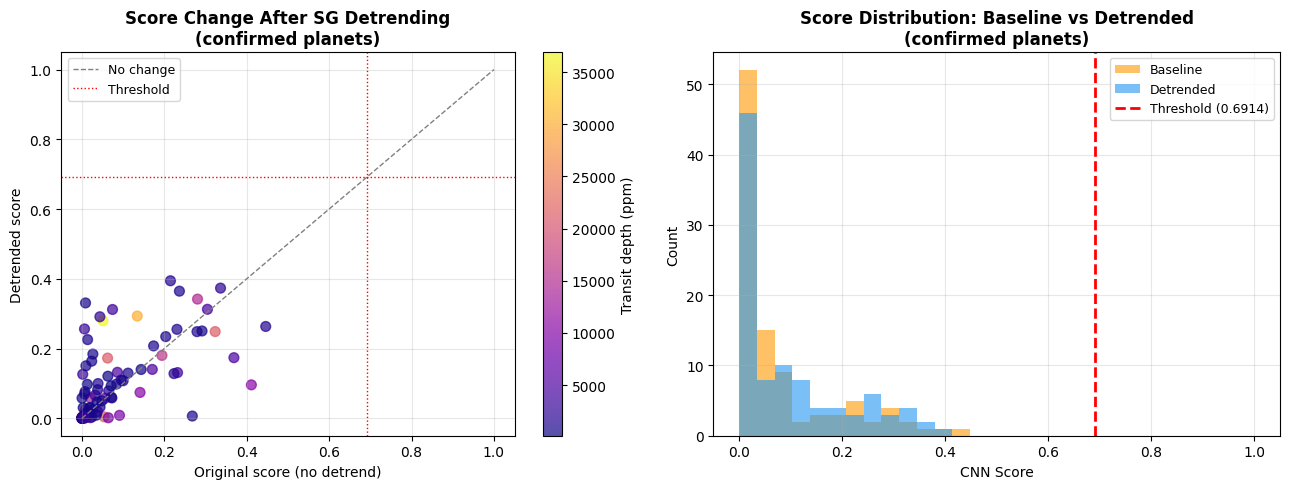

Saved: results/week9/detrend_comparison.png


In [33]:
# ── Rescore all 100 planets with detrending ───────────────────────────────────
DETREND_CACHE = 'results/week9/cache/scores_detrended.csv'

if os.path.exists(DETREND_CACHE):
    det_cache   = pd.read_csv(DETREND_CACHE)
    cached_det  = set(det_cache['kepid'].astype(int).tolist())
    det_results = det_cache.to_dict('records')
    print(f'Detrend cache loaded: {len(det_cache)} stars')
else:
    det_results = []
    cached_det  = set()
    print('No detrend cache — starting fresh')

planets_all = df[df['true_label'] == 1]['kepid'].tolist()
print(f'Total planets to rescore with detrending: {len(planets_all)}')

for i, kepid in enumerate(planets_all):
    if kepid in cached_det:
        continue

    orig_row   = df[df['kepid'] == kepid].iloc[0]
    orig_score = orig_row['score']

    print(f'  [{i+1}/{len(planets_all)}] KIC {kepid} '
          f'(depth={orig_row["koi_depth"]:.0f}, '
          f'period={orig_row["koi_period"]:.2f}d)...')

    new_score, err = score_star_detrended(kepid, model)
    delta = (new_score - orig_score) if not np.isnan(new_score) else np.nan
    print(f'    orig={orig_score:.4f}  detrended={new_score:.4f}  delta={delta:+.4f}')

    det_results.append({
        'kepid':      kepid,
        'orig_score': orig_score,
        'det_score':  new_score,
        'delta':      delta,
        'koi_depth':  orig_row['koi_depth'],
        'koi_period': orig_row['koi_period'],
        'snr_tier':   orig_row['snr_tier'],
        'true_label': int(orig_row['true_label']),
        'error':      err
    })
    pd.DataFrame(det_results).to_csv(DETREND_CACHE, index=False)

det_df = pd.DataFrame(det_results)

# ── Results comparison ────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'DETRENDING EXPERIMENT RESULTS')
print(f'{"="*55}')
print(f'{"Metric":<30} {"Baseline":>10} {"Detrended":>10}')
print(f'{"-"*55}')
for label, threshold in [('Score > 0.6914', WILD_THRESHOLD),
                          ('Score > 0.50',   0.50),
                          ('Score > 0.10',   0.10)]:
    base = (det_df['orig_score'] > threshold).sum()
    dett = (det_df['det_score']  > threshold).sum()
    print(f'{label:<30} {base:>10} {dett:>10}')
print(f'{"Mean score":<30} '
      f'{det_df["orig_score"].mean():>10.4f} '
      f'{det_df["det_score"].mean():>10.4f}')
print(f'{"="*55}')

print(f'\nDetection by SNR tier:')
print(f'{"Tier":<8} {"N":>4} {"Baseline":>10} {"Detrended":>10}')
for tier in ['high', 'mid', 'low']:
    sub  = det_df[det_df['snr_tier'] == tier]
    n    = len(sub)
    base = (sub['orig_score'] > WILD_THRESHOLD).sum()
    dett = (sub['det_score']  > WILD_THRESHOLD).sum()
    print(f'{tier:<8} {n:>4} {base:>10} {dett:>10}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(det_df['orig_score'], det_df['det_score'],
                c=det_df['koi_depth'], cmap='plasma', alpha=0.7, s=50)
ax.plot([0,1],[0,1], '--', color='gray', lw=1, label='No change')
ax.axhline(WILD_THRESHOLD, color='red', ls=':', lw=1)
ax.axvline(WILD_THRESHOLD, color='red', ls=':', lw=1, label='Threshold')
ax.set_xlabel('Original score (no detrend)')
ax.set_ylabel('Detrended score')
ax.set_title('Score Change After SG Detrending\n(confirmed planets)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='Transit depth (ppm)')

ax = axes[1]
bins = np.linspace(0, 1, 30)
ax.hist(det_df['orig_score'], bins=bins, alpha=0.6,
        color='#FF9800', label='Baseline')
ax.hist(det_df['det_score'],  bins=bins, alpha=0.6,
        color='#2196F3', label='Detrended')
ax.axvline(WILD_THRESHOLD, color='red', ls='--', lw=2,
           label=f'Threshold ({WILD_THRESHOLD})')
ax.set_xlabel('CNN Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: Baseline vs Detrended\n(confirmed planets)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/week9/detrend_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/week9/detrend_comparison.png')

## Week 9A Summary — Generalisation Study

### Sample Design
- 300 stars total — zero overlap with Week 7 or Week 8
- 100 confirmed planet hosts (stratified by SNR)
- 100 FALSE POSITIVE KOIs
- 100 CANDIDATE KOIs (ambiguous)

| Group | N | SNR Range |
|---|---|---|
| Planet hosts — High SNR | 30 | ≥ 200 |
| Planet hosts — Mid SNR | 40 | 50 – 200 |
| Planet hosts — Low SNR | 30 | < 50 |
| FALSE POSITIVE KOIs | 100 | Mixed |
| CANDIDATE KOIs | 100 | Mixed |

---

### Pipeline
TAP query → LC download → Week 2 preprocessing → CNN score → calibrated threshold (0.6914) → EB filter → metrics

---

### Results

| Evaluation | Planets Detected | F1 | FPR |
|---|---|---|---|
| Full catalog — baseline | 0 / 100 (0%) | 0.000 | 0.030 |
| Target population (period<10d, depth>3000ppm) | 0 / 23 (0%) | 0.000 | 0.030 |
| After Savitzky-Golay detrending | 0 / 100 (0%) | 0.000 | 0.030 |
| Mean planet score — baseline | — | 0.0794 | — |
| Mean planet score — detrended | — | 0.0956 | — |

---

### Root Cause — Three-Layer Investigation

**Layer 1 — Pipeline is correct**
Kepler-2b rescored at exactly 0.976651 through the Week 9 pipeline — identical to Week 7.
Download, preprocessing, and scoring are verified correct.

**Layer 2 — Stellar variability contamination**
K00254.01: depth=36912 ppm (deeper than any Week 7 training star), SNR=1342, period=2.46d.
Expected score: ~0.9. Actual score: 0.051.
Cause: stellar oscillations ±2% amplitude. Gaussian σ=10 smoothing averages transit dips
INTO the variability. CNN receives a sine wave instead of a transit comb.

**Layer 3 — Training distribution mismatch (primary cause)**
Detrending raised mean score from 0.0794 → 0.0956 but zero planets crossed the 0.6914 threshold.
The model learned a narrow signal template from the competition dataset —
quiet, short-period Hot Jupiters with clean periodic dips.
The broader Kepler population does not match this template even after detrending.

---

### What the Model Actually Learned
- **Not:** "a periodic flux dip exists"
- **Yes:** "a periodic narrow spike comb of a specific width and shape"
- This template matches only low-activity, short-period Hot Jupiters
- Everything else — active stars, long-period planets, multi-planet systems — scores near zero

---

### EB Filter on Week 9A Sample
- 8 stars flagged at threshold 0.6914 — all false positives
- 2/8 caught by EB filter (25%)
- 0 true planets flagged — EB filter causes no collateral damage
- Lower sample size than Week 8 because threshold 0.6914 flags very few stars

---

### Key Findings for Paper

1. **Detection rate collapses to 0% outside the training population**
   The model is a specialist, not a generalist. This is expected and publishable.

2. **Stellar variability is the hard failure mode**
   Proven at signal level via waveform comparison — not just a metric observation.

3. **Detrending is insufficient alone**
   SG detrending shifts scores upward but cannot bridge the training distribution gap.
   Retraining on a diverse, activity-stratified dataset is required.

4. **EB filter remains robust**
   Zero false rejections of true planets across both Week 8 and Week 9A samples.

---

### What Week 9A Proved
- ✅ Pipeline is correct — verified by rescoring Week 7 stars identically
- ✅ Root cause identified — stellar variability + training distribution mismatch
- ✅ Detrending tested and quantified — insufficient alone
- ✅ EB filter validated on independent sample — no collateral damage
- ✗ Detection rate on broader population — 0% (model limitation, not pipeline bug)
